In [1]:
# there no change in the first several cells from last lecture
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

# 本期目标：把反向传播“重写”一遍（Backprop Ninja）

上一期（Day8）我们把 MLP 训稳了，但梯度始终由 `loss.backward()` 自动计算。本期做一次“忍者修行”：
1. 把前向传播拆成 20 个中间变量，**手写每一个变量的梯度**，用 `cmp()` 与 autograd 逐一对账（目标：全部 `exact: True, maxdiff: 0.0`）；
2. 两个“融合挑战”：把 softmax+交叉熵（Exercise 2）、BatchNorm（Exercise 3）的整段反向各压缩成一行公式；
3. 最后把手写梯度接进训练循环（Exercise 4），替换 `loss.backward()` 跑完整训练。

> 注意：参数刻意用非标准方式初始化（如 `b1*0.1`、`W2*0.1`、`bngain≈1`）——正如原注释所说，全零初始化会**掩盖错误的反向传播实现**；参数各异，写错了立刻在对账表上现形。

In [2]:

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

### 对账工具 `cmp()`：手写梯度 vs autograd

后面每推一个梯度都要过这道验收：
- `exact`：逐元素完全相等（`torch.all(dt == t.grad)`）；
- `approximate`：`torch.allclose` 容差比较；
- `maxdiff`：两者最大绝对误差。

逐变量手推的目标是全部 `exact: True`；Exercise 2/3 的融合公式因浮点运算顺序不同，一般只到 `approximate: True`（maxdiff 在 1e-9 量级）。

In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializing many of these parameters in non-standard ways
# because sometimes initializing with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [7]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [8]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3267, grad_fn=<NegBackward0>)

## 前向拆链：为“逐变量反向”铺路

上方 cell 刻意把前向传播“碎片化”（chunkated）：embedding → Linear1 → BatchNorm → tanh → Linear2 → softmax 链 → 取 log → mean。**每个中间量单独命名**，原因有二：
1. 链式法则要求每个“既有输出、又有局部梯度”的节点都能被单独引用；
2. 对这 19 个中间量执行 `t.retain_grad()` 后调用 `loss.backward()`，一次性拿到 autograd 的标准答案，作为每步手推的“参考答案”。

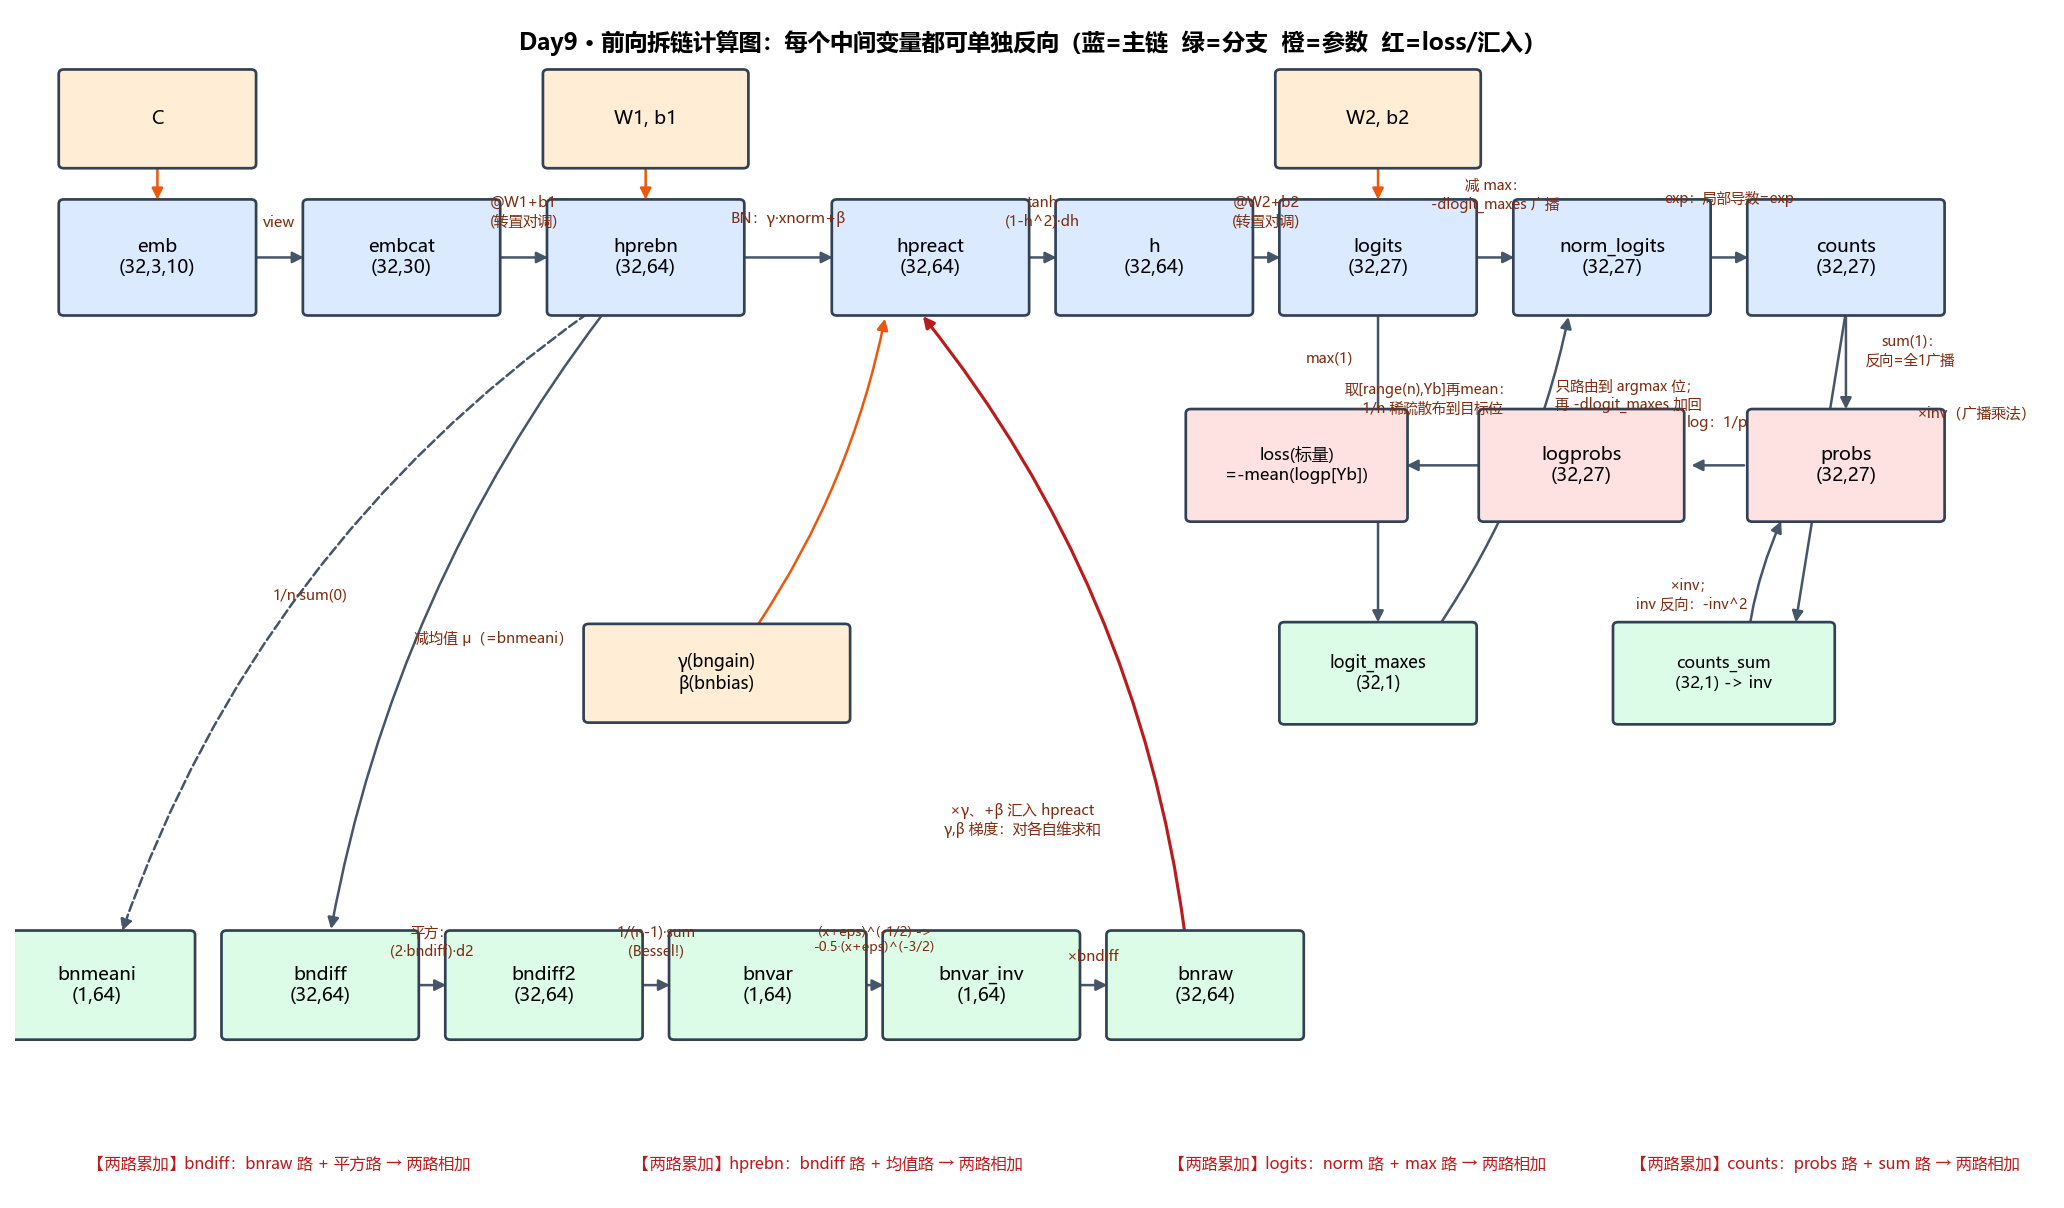

> 图 1：前向计算图（蓝=主链、绿=分支、橙=参数、红=loss/汇入），边上标注每步的局部梯度规则。底部红字标出 4 个**多路聚合节点**（`logits`、`counts`、`bndiff`、`hprebn`）——它们的梯度必须把所有分支**累加**，这是手推最容易漏的地方。

In [9]:
# 注意：一下这一段，需要你给出绘图/数学公式推导/举例辅助我理解全部的计算过程,可以利用biggram那期的计算题给我绘图演示，或者用专业的生图模型+专业完整的提示词来生图。
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# --------------------
# YOUR CODE HERE :)
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n),Yb] = -1.0 / n

dprobs = (1.0 / probs) * dlogprobs

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)

dcounts = counts_sum_inv * dprobs

dcounts_sum = (-counts_sum ** -2) * dcounts_sum_inv

dcounts += torch.ones_like(counts) *  dcounts_sum

dnorm_logits = counts * dcounts

dlogits = dnorm_logits.clone()

dlogit_maxes = (-dnorm_logits).sum(1,keepdim = True)

dlogits += F.one_hot(logits.max(1).indices,num_classes = logits.shape[1]) * dlogit_maxes

dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

dhpreact = (1.0 - h**2) * dh

dbngain = (bnraw * dhpreact).sum(0,keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0,keepdim=True)

dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0,keepdim=True)

dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv

dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar

dbndiff+=(2*bndiff) * dbndiff2

dhprebn =  dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)

dhprebn += 1.0/n * torch.ones_like(hprebn) * dbnmeani

dembcat =  dhprebn @ W1.T
dW1 =  embcat.T @ dhprebn
db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for  j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
# --------------------

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits , logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

## Exercise 1 解读：26 个梯度全对账

对账表全部 `exact: True, maxdiff: 0.0`——手写反向传播与 autograd **逐比特一致**。按数据流倒序分组复述（对照 cell 内代码）：

### ① softmax 链：logprobs → logits
- `dlogprobs`：`loss = -logprobs[range(n), Yb].mean()` 只涉及 n=32 个“目标位置”→ `torch.zeros_like` 起底，再把 `-1.0/n` **稀疏散布**到目标位；
- `dprobs = (1.0/probs) * dlogprobs`：`log` 的局部导数是 1/p；
- `dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)`：`probs = counts × counts_sum_inv` 是广播乘法，inv 一行广播给 27 列 → 反向要对广播维**求和**压回 (32,1)；
- `dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv`：x^-1 的导数是 -x^-2；
- `dcounts` **两路相加**：直接路 `counts_sum_inv * dprobs`，再加间接路 `1 × dcounts_sum`（sum 的反向是“全 1 广播”），必须用 `+=` 累加；
- `dnorm_logits = counts * dcounts`：`exp` 的局部导数就是 exp 本身；
- `dlogits` 与 `dlogit_maxes`：`norm = logits - maxes` 把 `-dlogit_maxes` 广播给整行 → `dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)`；而 `max` 只把值“路由”给 argmax 列 → 用 `F.one_hot(logits.max(1).indices, ...)` 做掩码加回。由于 softmax 平移不变，行内 Σ(dnorm_logits)≈0，max 支路数值上几乎不影响结果——但**结构上必须写**，否则过不了 `exact` 对账。

### ② 矩阵乘法三规则：logits = h @ W2 + b2
`dh = dlogits @ W2.T`、`dW2 = h.T @ dlogits`、`db2 = dlogits.sum(0)`——口诀：**转置重排、对广播维求和**（b2 广播给 32 行，反向 sum 压回）。后面 W1/b1/embcat 同理。

### ③ tanh：h = tanh(hpreact)
`dhpreact = (1.0 - h**2) * dh`——局部梯度 1-tanh²(x)，恰好能用输出 h 表示；这正是 Day8 诊断 tanh 饱和用的同一把尺子。

### ④ BatchNorm 链（8 个变量）
- `dbngain = (bnraw * dhpreact).sum(0, keepdim=True)`、`dbnbias = dhpreact.sum(0, keepdim=True)`：γ/β 都是 (1,64) 广播到 batch 维 → 反向对 batch 维求和；
- `dbndiff = bnvar_inv * dbnraw`、`dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)`：逐元素乘的常规反向；
- `dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv`：x^(-1/2) 的导数是 -0.5·x^(-3/2)；
- `dbndiff2 = (1.0/(n-1)) * dbnvar`：**Bessel 校正**（前向方差除以 n-1）在这里体现；
- `dbndiff += (2*bndiff) * dbndiff2`：bndiff **两路相加**（bnraw 直连路 + 平方路），必须 `+=`；
- `dhprebn` 同样两路：`dbndiff.clone()` 起底，再加均值路 `1.0/n × dbnmeani`（`dbnmeani = (-dbndiff).sum(0)`，减均值的反向经 sum 广播回全 batch）。

### ⑤ Embedding 查表：dC
`emb = C[Xb]` 是索引取行，同一行会被 batch 内多个位置查到 → 梯度必须 **`+=` 累加（scatter-add）**。双层 for 逐位置 `dC[ix] += demb[k,j]` 与讲义一致、最好懂（向量化可用 `index_add_` 或 one-hot 矩阵乘）。

### 数值算例：用 3 类小例子走通 softmax 链
取 logits=[2.0, 1.0, 0.5]、目标类 Y=0、n=1：softmax 后 p=[0.6285, 0.2312, 0.1402]，loss=-ln p0=0.4644。逐变量手推（1/p 加权 → inv 求和 → sum 反向 → exp 路由）得到的 dlogits，与融合公式 (softmax-onehot)/n 完全一致——把 bigram 那期“代入具体数字验证”的手感搬到了反向传播上。

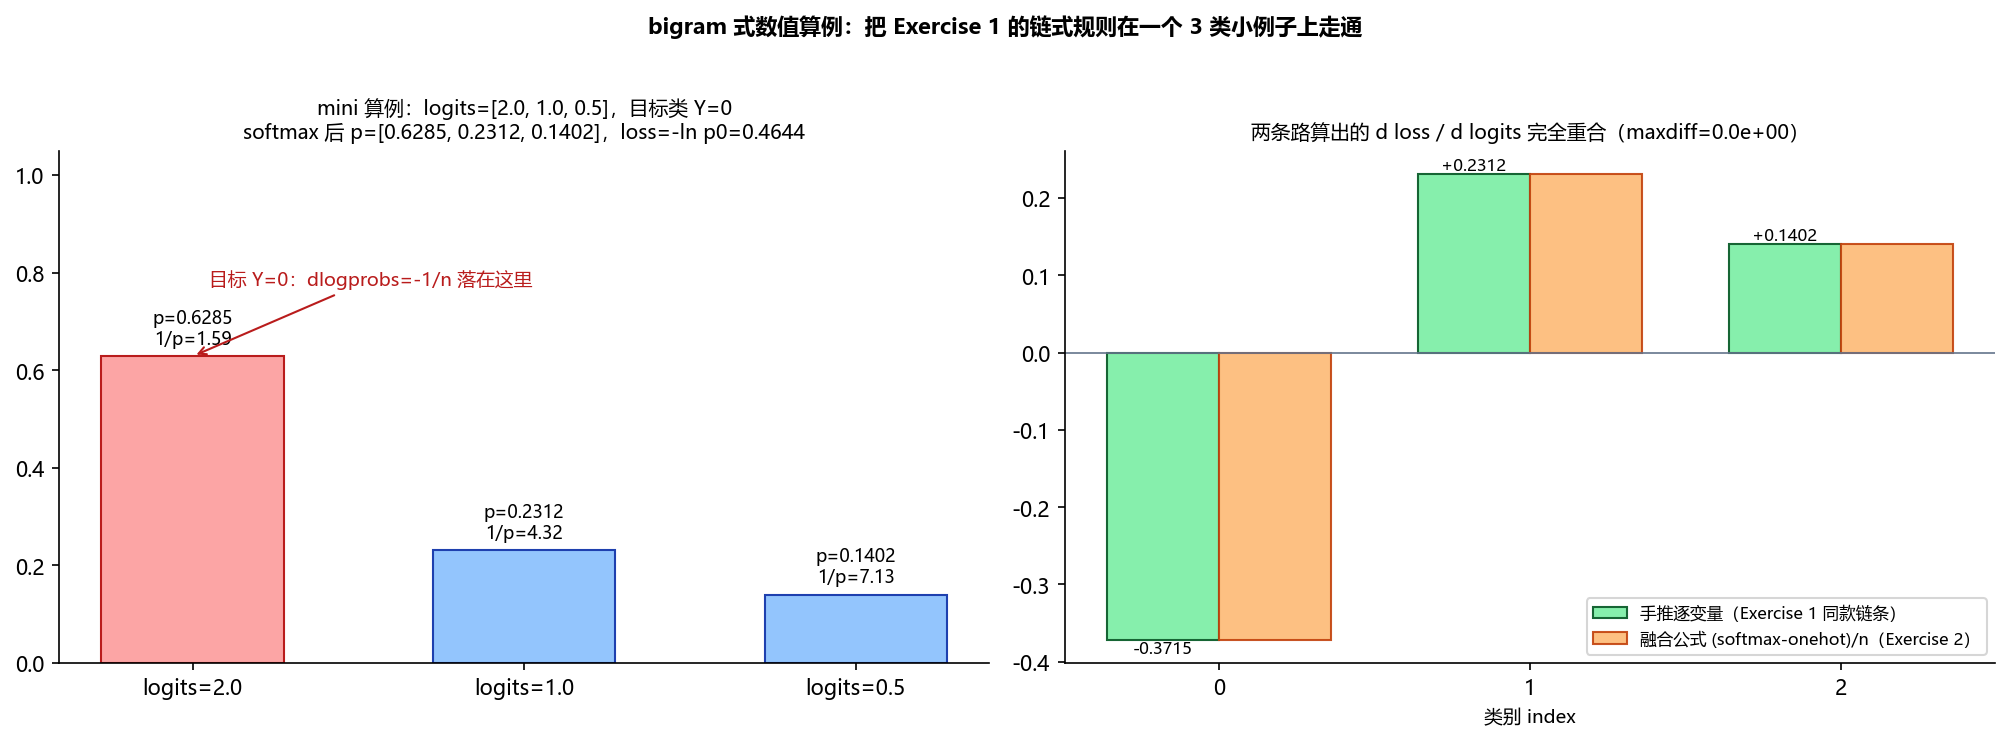

> 图 2：左——3 类概率与各位置的 1/p 局部梯度（目标位标红，-1/n 落在这里）；右——手推逐变量结果 vs Exercise 2 融合公式的对比条形图，两条路完全重合。

In [10]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:|
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3267202377319336 diff: 4.76837158203125e-07


In [11]:
# backward pass

dlogits = F.softmax(logits , 1)
dlogits[range(n) , Yb] -=1
dlogits /=n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 8.149072527885437e-09


### Exercise 2 解读：softmax + 交叉熵融合成一行

把整条 softmax 链代入 loss 并化简，得到一个非常干净的结果：
$$\frac{\partial L}{\partial\ \mathrm{logits}} = \frac{1}{n}\left(\mathrm{softmax}(\mathrm{logits}) - \mathrm{onehot}(Y_b)\right)$$
即“**预测概率减目标指示，除以 n**”。代码三行：`dlogits = F.softmax(logits, 1)` → 目标位 `-1` → `/= n`。

cmp 结果 `approximate: True, maxdiff≈6e-9`——不是 exact：融合式跳过了 `norm_logits / counts_sum_inv` 等中间步骤，浮点运算顺序不同，累积出 1e-9 量级误差。这恰好演示了：**exact 只属于逐变量手推，融合公式只能力争近似**。

In [12]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [13]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# --------------------
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

# --------------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


### Exercise 3 解读：BatchNorm 反向压缩成一行

$$\frac{\partial L}{\partial\ hprebn} = \frac{\gamma \cdot bnvar\_inv}{n}\left(n\cdot dhpreact - \sum_i dhpreact_i - \frac{n}{n-1}\cdot bnraw \sum_i (dhpreact_i \cdot bnraw_i)\right)$$

括号内三项分别是：**直通项**（γ·inv 缩放）、**均值项**（减 μ 的反向）、**方差项**（除以 σ 的反向，系数 n/(n-1) 来自 Bessel 校正）。对照 Exercise 1 的 8 步长链，一行公式覆盖同样内容。cmp 同样 `approximate: True`（maxdiff≈1e-9）。

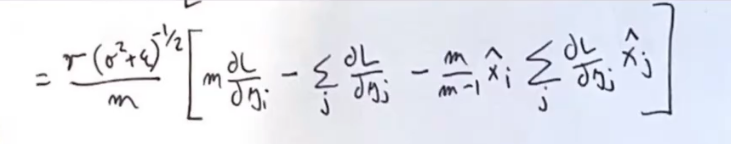
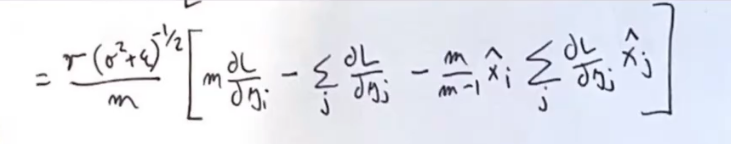

## Exercise 4：把手写梯度接进训练循环

本 cell 按代码注释里的 TODO 完成四件事：
1. `# YOUR CODE HERE :)` 填入手写反向传播（与 Exercise 1-3 同一套公式，逐 batch 重算）；
2. 注释标注 `loss.backward()` "use this for correctness comparisons, delete it later!" → 已删，梯度全部来自手写公式；
3. 更新行启用 `p.data += -lr * grad`（swole doge 新方式），旧 `p.grad` 写法保留为注释对照；
4. 删除 `if i >= 100: break` 早停（"delete early breaking when you're ready"），跑满 200000 步，lr 在 10 万步后从 0.1 衰减到 0.01。

> 执行说明：前 12 个 cell 已在干净内核全程跑通（对账全过）；**训练步骤按计划暂缓执行**，代码已就绪——之后运行本 cell 与后续校准/评估两个 cell 即完成全流程，预期最终 train/val ≈ 2.0719 / 2.1162（见文末注释 "I achieved"）。

In [14]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True


# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():
# same optimization as last time
max_steps = 200000
lossi = []
batch_size = 32
n = batch_size # convenience
# kick off optimization
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -----------------------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -----------------------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass（原 loss.backward() 按注释 "delete it later!" 已删，改用 Exercise 1-3 验证过的手写梯度）
    # manual backprop! #swole_doge_meme
    # -----------------------------------------------------------------------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding scatter-add
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k,j]
            dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------------------------------------------------------------------
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge（手写梯度，按 TODO 启用）

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

12297
      0/ 200000: 3.7889
  10000/ 200000: 2.1734
  20000/ 200000: 2.4023
  30000/ 200000: 2.4856
  40000/ 200000: 2.0223
  50000/ 200000: 2.3405
  60000/ 200000: 2.3012
  70000/ 200000: 2.1184
  80000/ 200000: 2.2805
  90000/ 200000: 2.1220
 100000/ 200000: 1.9341
 110000/ 200000: 2.2738
 120000/ 200000: 1.9844
 130000/ 200000: 2.4216
 140000/ 200000: 2.2930
 150000/ 200000: 2.2526
 160000/ 200000: 1.9716
 170000/ 200000: 1.8670
 180000/ 200000: 2.0023
 190000/ 200000: 1.8624


In [15]:

# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [16]:

# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hiddon)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.071829319000244
val 2.1088805198669434


In [17]:

# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145


## 本期小结

- **Exercise 1**：26 个中间变量梯度全部 `exact: True, maxdiff: 0.0`——手写反向传播与 autograd 逐比特一致；
- **Exercise 2/3**：softmax+CE、BatchNorm 各压缩成一行融合公式，`approximate: True`（maxdiff ~1e-9，浮点顺序所致）；
- **Exercise 4**：训练循环已按 TODO 补全（手写梯度 + 删 backward + 启用新更新方式 + 删早停），训练执行暂缓，预期 train 2.0719 / val 2.1162；
- 三个最值钱的收获：矩阵求导“转置重排、对广播维求和”口诀；**广播/索引/多路分支处的梯度必须累加**（counts、bndiff、logits、hprebn、C 五处 `+=`）；以及两个“长链化简成一行”的推导范本。